# EcoHome Energy Advisor - Agent Run & Evaluation

In this notebook, you'll run the Energy Advisor agent with various real-world scenarios and see how it helps customers optimize their energy usage.

## Learning Objectives
- Create the agent's instructions
- Run the Energy Advisor with different types of questions
- Evaluate response quality and accuracy
- Measure tool usage effectiveness
- Identify areas for improvement
- Implement evaluation metrics

## Evaluation Criteria
- **Accuracy**: Correct information and calculations
- **Relevance**: Responses address the user's question
- **Completeness**: Comprehensive answers with actionable advice
- **Tool Usage**: Appropriate use of available tools
- **Reasoning**: Clear explanation of recommendations


## 1. Import and Initialize

In [1]:
import os
from datetime import datetime

from langchain_openai import ChatOpenAI
from langchain_core.messages import AIMessage
from langchain_core.prompts import ChatPromptTemplate

from pydantic import BaseModel, Field
import matplotlib.pyplot as plt

from agent import Agent
from tools import TOOL_KIT

In [2]:
ECOHOME_SYSTEM_PROMPT = """
You are an assistent bot for finding optimization tips for an ecohome user to minimize energy consumption cost.

Your primary function is to act as a **Reasoning Engine** that coordinates the use of specialized tools and integrates their data to generate a comprehensive solution.

Make decisions about:
1. Which retrieved documents are pertinent to the user query (make use of the search_energy_tips tool)
2. Whether you need to ask for weather and energy generation forecast (with the get_weather_forecast tool)
3. Calling the API for getting electricity prices (the tool's name is get_electricity_prices, each day has the same pricing)
4. How to make use of past energy consumption (query_energy_usage or just get_recent_energy_summary)
5. ...and past solar energy generation (query_solar_generation)

IMPORTANT: Feel free to summarize the results of previous tool uses and to extract only information relevant for the user query, but don't use any tool more than once (to avoid reaching recursion limit).

The final recommendation should be structured into two parts: 
1. First, longer part explaining which tools were the most imporatant and how their outputs contributed to the final tip, and
2. Shorter, two- or three-sentences long tip 
"""

In [ ]:
TEMPERATURES = [0.0, 0.1, 0.3, 0.4]
# TEMPERATURES = [0.0, 0.1]

ecohome_agent = Agent(
    model='gpt-4o-mini',
    instructions=ECOHOME_SYSTEM_PROMPT,
    temperature=TEMPERATURES[0],
)

In [4]:
response = ecohome_agent.invoke(
    question="When should I charge my electric car tomorrow to minimize cost and maximize solar power?",
    context="Location: San Francisco, CA"
)

In [5]:
print(response["messages"][-1].content)

To determine the optimal time to charge your electric car tomorrow, I utilized several tools to gather relevant data:

1. **Weather Forecast**: The weather forecast for San Francisco indicates that solar irradiance will be highest between 8 AM and 12 PM, with peak solar power around 10 AM and 12 PM. This suggests that these hours are the best for maximizing solar power usage.

2. **Electricity Prices**: The electricity pricing for tomorrow is consistent throughout the day at $0.10 per kWh. This means there is no financial advantage to charging at a specific time based on electricity rates alone.

3. **Recent Energy Summary**: The recent energy summary indicates no significant solar generation or energy consumption, which means you can plan your charging without considering past usage patterns.

Based on this information, the best time to charge your electric car to maximize solar power is between 8 AM and 12 PM when solar irradiance is at its peak. Since electricity prices are constant

In [6]:
print("TOOLS:")
for msg in response["messages"]:
    obj = msg.model_dump()
    if obj.get("tool_call_id"):
        print("-", msg.name)

TOOLS:
- get_weather_forecast
- get_electricity_prices
- get_recent_energy_summary


## 2. Define Test Cases

In [7]:
test_cases = [
    {
        "id": "ev_charging_1",
        "question": "When should I charge my electric car tomorrow to minimize cost and maximize solar power?",
        "expected_tools": ["get_weather_forecast", "get_electricity_prices"],
        "expected_response": "The response should contain time recommendation, cost analysis and solar consideration",
    },
    {
        "id": "ev_charging_2",
        "question": (
            "When should I start charging my EV to minimize cost? I need it in the morning, at around 7am, and it typically takes 8h to charge."
            " I was thinking of charging it right after I come back home (4pm), but then I realized I can save up money if I used a different strategy."
            " Please, compare your recommendsd strategy with the one I was initially thinkining of, and tell me what the savings might be if I followed your suggestions."
        ),
        "expected_tools": ["search_energy_tips", "calculate_energy_savings"],
        "expected_response": "The response should suggest charging the EV during the night, OR during the day if the weather is sunny.",
    },
    {
        "id": "ev_charging_3",
        "question": (
            "Give me tips on how and when should I charge my EV? Ignore the weather forecast, I'm interested in general tips."
        ),
        "expected_tools": ["search_energy_tips", "calculate_energy_savings"],
        "expected_response": "The response should suggest charging the EV during the night, OR during the day if the weather is sunny.",
    },
    {
        "id": "thermostat_1",
        "question": (
            "How should I program my thermostat to minimize costs? I'm at work between 7am and 4pm, but I'd like to come back"
            " to a cosy home with 20°C."
        ),
        "expected_tools": ["get_weather_forecast"],
        "expected_response": "The response should include time information and a summary of cost savings."
    },
    {
        "id": "thermostat_2",
        "question": (
            "Give me a summary of general tips about cost-minimizing of the HVAC."
        ),
        "expected_tools": ["search_energy_tips"],
        "expected_response": "The response should provide tips gathered from "
    },
    {
        "id": "thermostat_3",
        "question": (
            "Take a look at my previous HVAC usage and tell me what I can improve. Take also into account the weather we had those day and my solar energy generation."
        ),
        "expected_tools": ["query_energy_usage", "query_solar_generation", "search_energy_tips"],
        "expected_response": "The response"
    },
    {
        "id": "appliance_1",
        "question": "Give me a rundown of my appliances in the past. What consumes the most energy?",
        "expected_tools": ["query_energy_usage"],
        "expected_response": "I think HVAC and EV are the most energy-intensive appliances, this is what the assistant should point to"
    },
    {
        "id": "appliance_2",
        "question": (
            "Take a look at electricity prices and suggest which appliances you think I could use more during the night (making use of off-peak electricity prices)"
            " and which hours during the day are the best for other appliacens given that those are the ones in which my solar generation is the highest (based on past solar energy generation)"
        ),
        "expected_tools": ["query_energy_usage", "query_solar_generation"],
        "expected_response": "The assistant should give suggestions about some appliances that can be used during the night, and some appliances being used close to noon when solar power is most available",
    },
    {
        "id": "solar_1",
        "question": (
            "Give me a set of guidelines about how to make the most out of my solar energy infrastructure (panels + storage) but without taking"
            " looking at my past energy generation, only by searching for energy tips in the available documents."
        ),
        "expected_tools": ["search_energy_tips"],
        "expected_response": "The response should suggest making use of the generated energy close to noon and have some suggestions about energy storage",
    },
    {
        "id": "solar_2",
        "question": (
            "I want to maximize my self-consumption of solar energy today. Based on the current weather forecast "
            "and my historical energy usage patterns, when should I run my washing machine (high-power appliance) "
            "to ensure it's powered entirely by my panels, and not the grid?"
        ),
        "expected_tools": ["get_weather_forecast", "query_energy_usage", "search_energy_tips"],
        "expected_response": "The response must identify the predicted peak solar hour (from weather forecast) and compare it against the user's historical load (from query_energy_usage) to find a time slot with maximum solar surplus. It should recommend a specific time range (e.g., 11 AM - 2 PM) and include a tip from the documents.",
    },
    {
        "id": "solar_3",
        "question": (
            "I have an energy storage battery. What are the general best practices for setting its operational mode (e.g., Self-Consumption vs. ToU Arbitrage) "
            "given my city's common Time-of-Use structure?"
        ),
        "expected_tools": ["search_energy_tips", "get_electricity_prices"], 
        "expected_response": "The response must utilize the electricity prices to categorize the user's ToU structure (e.g., high differential or flat rate) and then use the tips document to recommend the appropriate battery mode (e.g., ToU Arbitrage mode) based on that price data.",
    },
    {
        "id": "cost_1",
        "question": (
            "It's winter, and my heating bill is too high. Considering tomorrow's electricity prices and my home's typical high-demand hours, "
            "should I pre-heat the house at 5 AM or wait until I get home at 4 PM?"
        ),
        "expected_tools": ["get_weather_forecast", "get_electricity_prices", "query_energy_usage"],
        "expected_response": "The response must compare the price of electricity at 5 AM (Off-Peak) vs. 4 PM (likely Peak or Mid-Peak) and the forecasted temperature to recommend the cheapest, most efficient time to pre-heat (e.g., use off-peak power at 5 AM or rely on passive solar gain later if possible).",
    },
    {
        "id": "cost_2",
        "question": (
            "I heard about 'Deep Cycling' on batteries. Give me the simplest, most cost-effective guideline for managing my solar battery's discharge level."
        ),
        "expected_tools": ["search_energy_tips"],
        "expected_response": "The response must retrieve the tip regarding 'Avoid Deep Cycling' or 'Optimal State of Charge' from the documents and present it as the primary cost-saving guideline for battery longevity.",
    },
    {
        "id": "seasonal_1",
        "question": (
            "I'm adjusting my smart home settings for the summer. What are the top two general, non-appliance-specific tips for maximizing savings during hot weather, according to your documents?"
        ),
        "expected_tools": ["search_energy_tips"], 
        "expected_response": "The response should focus on summer-specific strategies such as increasing the AC set point (general advice) or adjusting battery reserve levels downwards (seasonal set points tip).",
    },
    {
        "id": "seasonal_2",
        "question": (
            "How does the change in solar generation between January and July affect my ideal electric car charging time? Use my historical solar generation data to provide context for this comparison."
        ),
        "expected_tools": ["query_solar_generation", "search_energy_tips"],
        "expected_response": "The response must use the historical data (query_solar_generation) to show the difference in peak hours/total generation between the two months. The tip should state that winter charging must rely on ToU rates (night) while summer charging can leverage daytime PV surplus (search_energy_tips).",
    },
]

if len(test_cases) < 10:
    raise ValueError("You MUST have at least 10 test cases")

## 3. Run Agent Tests

In [8]:
CONTEXT = "Location: San Francisco, CA"

In [11]:
print("=== Running Agent Tests ===")
test_results = {}

for temperature in TEMPERATURES:
    test_results[temperature] = []
    
    for i, test_case in enumerate(test_cases):
        print(f"\nTest {i+1}: {test_case['id']}")
        print(f"Question: {test_case['question']}")
        print("-" * 50)
        
        # Create a new agent and graph (with its state that doesn't accumulate too many messages)
        ecohome_agent = Agent(
            instructions=ECOHOME_SYSTEM_PROMPT,
            temperature=temperature,
        )
        
        try:
            # Call the agent
            response = ecohome_agent.invoke(
                question=test_case['question'],
                context=CONTEXT
            )
            
            # Store the result
            result = {
                'test_id': test_case['id'],
                'question': test_case['question'],
                'response': response,
                'expected_tools': test_case['expected_tools'],
                'expected_response': test_case['expected_response'],
                'timestamp': datetime.now().isoformat()
            }
            test_results[temperature].append(result)
                    
        except Exception as e:
            print(f"Error: {e}")
            result = {
                'test_id': test_case['id'],
                'question': test_case['question'],
                'response': f"Error: {str(e)}",
                'expected_tools': test_case['expected_tools'],
                'expected_response': test_case['expected_response'],
                'timestamp': datetime.now().isoformat(),
                'error': str(e)
            }
            test_results[temperature].append(result)

    print(f"\nCompleted {len(test_results[temperature])} tests for temperature {temperature:.2f}")


=== Running Agent Tests ===

Test 1: ev_charging_1
Question: When should I charge my electric car tomorrow to minimize cost and maximize solar power?
--------------------------------------------------

Test 2: ev_charging_2
Question: When should I start charging my EV to minimize cost? I need it in the morning, at around 7am, and it typically takes 8h to charge. I was thinking of charging it right after I come back home (4pm), but then I realized I can save up money if I used a different strategy. Please, compare your recommendsd strategy with the one I was initially thinkining of, and tell me what the savings might be if I followed your suggestions.
--------------------------------------------------

Test 3: ev_charging_3
Question: Give me tips on how and when should I charge my EV? Ignore the weather forecast, I'm interested in general tips.
--------------------------------------------------

Test 4: thermostat_1
Question: How should I program my thermostat to minimize costs? I'm at 

## 4. Evaluate Responses

In [12]:
evaluator_llm = ChatOpenAI(
    model='gpt-4o-mini',
    temperature=0.1,
    base_url="https://openai.vocareum.com/v1",
    api_key=os.getenv("VOCAREUM_API_KEY")
)

accuracy_definition = """
   - **Focus:** Factual correctness and logical soundness.
   - **Definition:** Did the final response adhere to known facts, provide mathematically plausible advice, and model the expected behavior correctly? (0=Completely wrong, 100=Perfectly sound and factually correct).
"""

relevance_definition = """
   - **Focus:** Directness in answering the user's query.
   - **Definition:** Did the response directly address every point in the user's QUESTION? Did it avoid introducing irrelevant or unsolicited information? (0=Irrelevant rambling, 100=Laser-focused on the question).
"""

completeness_definition = """
   - **Focus:** Fulfilling all mandated output requirements.
   - **Definition:** Did the response fulfill all structural and content requirements listed in the EXPECTED RESPONSE? (0=Missing key components, 100=All required elements present).
"""

usefulness_definition = """
   - **Focus:** Practicality and actionability of the advice.
   - **Definition:** Is the advice genuinely practical and actionable for the user? Does it provide a tangible "next step" or clear advice rather than just generic information? (0=Vague and unusable, 100=Clear, practical, and highly actionable).
"""

RESPONSE_EVALUATOR_SYSTEM_PROMPT = f"""
You are the **AI Assessment Specialist**, a rigorous and unbiased quality control agent. 
Your task is to critically evaluate a language model agent's response based on three inputs: 
1. The original user QUESTION.
2. The agent's FINAL RESPONSE.
3. The EXPECTED RESPONSE (the ground truth criteria for the test case).

You MUST generate a response that strictly adheres to the provided schema.

---
EVALUATION CRITERIA (Score 0-100):

1. **ACCURACY:** {accuracy_definition}

2. **RELEVANCE:** {relevance_definition}

3. **COMPLETENESS:** {completeness_definition}

4. **USEFULNESS:** {usefulness_definition}

Generate scores and detailed, unbiased justifications for each metric. The scores MUST be integers between 0 and 100.
"""

USER_QUERY_TEMPLATE = """
--- CONTEXT FOR EVALUATION ---
1. ORIGINAL QUESTION:
{question}

2. AGENT'S FINAL RESPONSE:
{final_response}

3. EXPECTED RESPONSE CRITERIA:
{expected_response}

--- TASK ---
Critique the Agent's Final Response based on the criteria above and output your scores and feedback based on the provided schema
"""

class ResponseEvaluation(BaseModel):
   """Structured response for the evaluation task."""
   comprehensive_feedback: str = Field(description="Feedback from the evaluator LLM about what went wrong and might be improved")
   accuracy_score: float = Field(description=f"{accuracy_definition}")
   relevance_score: float = Field(description=f"{relevance_definition}")
   completeness_score: float = Field(description=f"{completeness_definition}")
   usefulness_score: float = Field(description=f"{usefulness_definition}")


response_evaluation_prompt = ChatPromptTemplate.from_messages([
    ("system", RESPONSE_EVALUATOR_SYSTEM_PROMPT),
    ("human", USER_QUERY_TEMPLATE)
])

structured_response_evaluator_chain = response_evaluation_prompt | evaluator_llm.with_structured_output(ResponseEvaluation)


def evaluate_response(question, final_response, expected_response):
   """Evaluate a single response against expected response"""
   
   evaluation_response: ResponseEvaluation = structured_response_evaluator_chain.invoke({
       "question": question,
       "final_response": final_response,
       "expected_response": expected_response
   })
   
   return evaluation_response
    

In [13]:
response_evaluation_scores_and_feedback = {
    temperature: {attr_name: [] for attr_name in list(ResponseEvaluation.model_fields.keys())}
    for temperature in TEMPERATURES
}

for temperature in TEMPERATURES:
    print(f'Evaluation of responses for temperature: {temperature:.2f}')
    for one_test_result in test_results[temperature]:
        question = one_test_result['question']
        final_response = one_test_result['response']['messages'][-1]
        expected_response = one_test_result['expected_response']
        
        evaluation_response = evaluate_response(question, final_response, expected_response)
        evaluation_response_dump = evaluation_response.model_dump()
        
        for attr_name in response_evaluation_scores_and_feedback[temperature].keys():
            response_evaluation_scores_and_feedback[temperature][attr_name].append(evaluation_response_dump[attr_name])

Evaluation of responses for temperature: 0.00
Evaluation of responses for temperature: 0.10
Evaluation of responses for temperature: 0.30
Evaluation of responses for temperature: 0.40


In [14]:
tool_appropriateness_definition = """
Were the right tools selected for the task.
"""
tool_completeness_definition = """
Were all necessary tools used.
"""

TOOL_EVALUATOR_SYSTEM_PROMPT = f"""
You are the **AI Assessment Specialist**, a rigorous and unbiased quality control agent. 
Your task is to critically evaluate a language model agent's response and in particular: the tool use of the model.

You MUST generate a response that strictly adheres to the provided schema.

---
EVALUATION CRITERIA (Score 0-100):

1. **TOOL APPROPRIATENESS:** {tool_appropriateness_definition}

2. **TOOL COMPLETENESS:** {tool_completeness_definition}

You need to judge how relevant each of the expected tools really was.  

Generate scores and detailed, unbiased justifications for each metric. The scores MUST be integers between 0 and 100.
"""

USER_QUERY_TEMPLATE = """
--- CONTEXT FOR EVALUATION ---
1. ORIGINAL QUESTION:
{question}

2. TOOLS USED BY THE AGENT:
{tools_used}

3. EXPECTED TOOL USE:
{expected_tools}

--- TASK ---
Critique the Agent's tool use and the criteria above, and output your scores and feedback based on the provided schema.
"""

tool_evaluation_prompt = ChatPromptTemplate.from_messages([
    ("system", TOOL_EVALUATOR_SYSTEM_PROMPT),
    ("human", USER_QUERY_TEMPLATE)
])


class ToolUseEvaluatorResponse(BaseModel):
   """Structured response for the task of evaluating tool use."""
   comprehensive_feedback: str = Field(description="Feedback from the evaluator LLM about whether the used tools were sufficient and if anything could be improved here.")
   tool_appropriateness_score: float = Field(description=f"{tool_appropriateness_definition}")
   tool_completeness_score: float = Field(description=f"{tool_completeness_definition}")


structured_tool_evaluator_chain = tool_evaluation_prompt | evaluator_llm.with_structured_output(ToolUseEvaluatorResponse)


def evaluate_tool_usage(question, messages, expected_tools):
    """Evaluate if the right tools were used"""
    tools_used = []
    for message in messages:
        if isinstance(message, AIMessage) and message.tool_calls:
            tools_used.extend([tool_call['name'] for tool_call in message.tool_calls])
                    
    return structured_tool_evaluator_chain.invoke({
        'question': question,
        'tools_used': tools_used,
        'expected_tools': expected_tools,
    })

In [15]:
tool_use_evaluation_scores_and_feedback = {
    temperature: {attr_name: [] for attr_name in list(ToolUseEvaluatorResponse.model_fields.keys())}
    for temperature in TEMPERATURES
}

for temperature in TEMPERATURES:
    for test_case, test_result in zip(test_cases, test_results[temperature]):
        question = test_case['question']
        expected_tools = test_case['expected_tools']
        
        messages = test_result['response']['messages']
        
        tool_use_evaluation_response = evaluate_tool_usage(question, messages, expected_tools)
        tool_use_evaluation_response_dump = tool_use_evaluation_response.model_dump()
        
        for attr_name in tool_use_evaluation_scores_and_feedback[temperature].keys():
            tool_use_evaluation_scores_and_feedback[temperature][attr_name].append(tool_use_evaluation_response_dump[attr_name])

In [16]:
FEEDBACK_EVALUATOR_SYSTEM_PROMPT = f"""
You are the **AI Assessment Specialist**, a rigorous and unbiased quality control agent. 
Your task is to critically evaluate a language model agent's response and in particular: 
1. Summarize all feedback provided below into one comprehensive feedback.
2. Identify strenghts and weeknesses.
3. Provide recommendations for improvement.

You MUST generate a response that strictly adheres to the provided schema.
"""

USER_QUERY_TEMPLATE = """
--- CONTEXT FOR EVALUATION ---
1. RESPONSE FEEDBACKS:
{response_feedbacks}

2. TOOLS USE FEEDBACKS:
{tool_use_feedbacks}


--- TASK ---
Identify patterns within those two types of feedback and provide 
"""

feedback_evaluation_prompt = ChatPromptTemplate.from_messages([
    ("system", FEEDBACK_EVALUATOR_SYSTEM_PROMPT),
    ("human", USER_QUERY_TEMPLATE)
])


class FeedbackEvaluator(BaseModel):
   """Structured response for the task of evaluating tool use."""
   summary: str = Field(description="Summary of the feedbacks")
   strengths: str = Field(description="Areas in which the agent is performing well already")
   weaknesses: str = Field(description="Areas in which the agent would benefit most from improvements")


structured_feedback_evaluator_chain = feedback_evaluation_prompt | evaluator_llm.with_structured_output(FeedbackEvaluator)


def feedback_evaluation(response_feedbacks, tool_use_feedbacks):
    return structured_feedback_evaluator_chain.invoke({
        'response_feedbacks': response_feedbacks,
        'tool_use_feedbacks': tool_use_feedbacks,
    })

In [ ]:
feedback_evaluations = {}

for temperature in TEMPERATURES:
    for test_case in test_cases:        
        response_feedbacks = response_evaluation_scores_and_feedback[temperature]['comprehensive_feedback']
        tool_use_feedbacks = tool_use_evaluation_scores_and_feedback[temperature]['comprehensive_feedback']
        
        feedback_evaluations[temperature] = feedback_evaluation(response_feedbacks, tool_use_feedbacks)
        

# Generate overall report

## Response scores


Let's first take a look at the histograms of scores (accuracy, relevance, completeness, and usefulness) for the response evaluation:

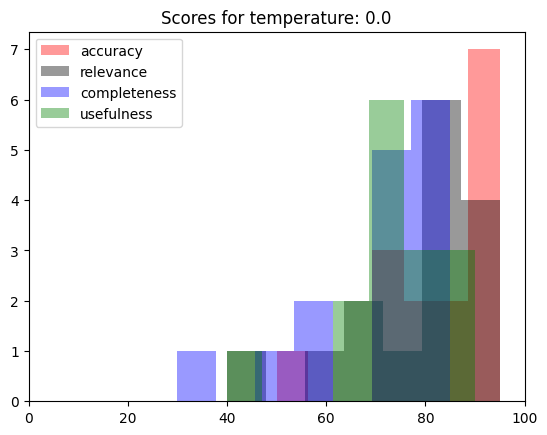

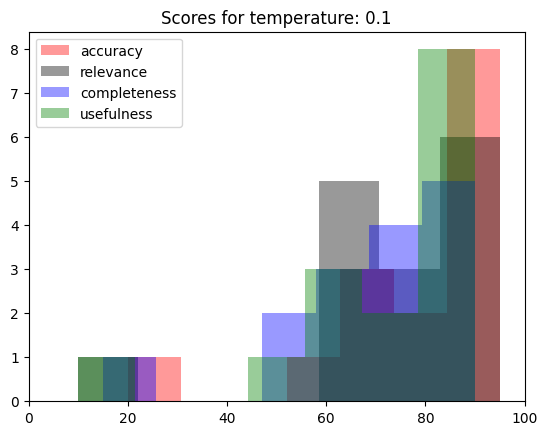

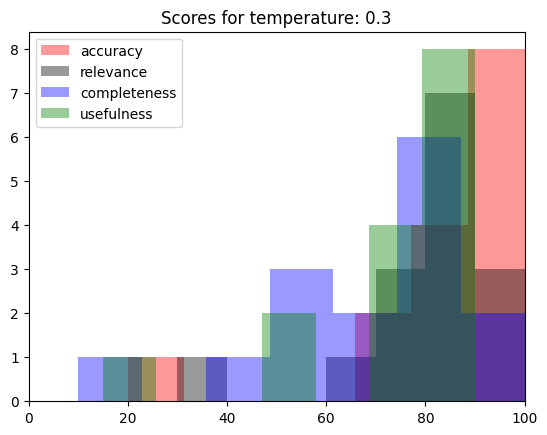

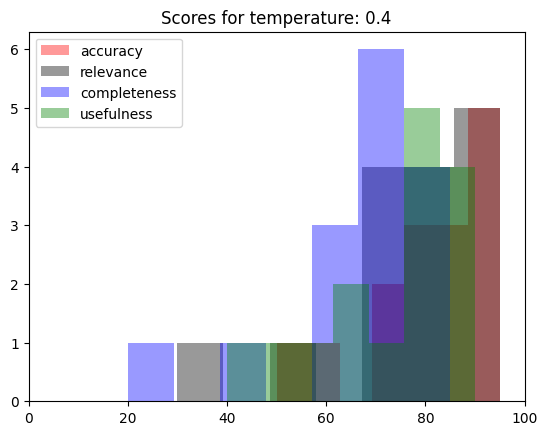

In [23]:
COLORS = {
 'accuracy_score': 'red',
 'relevance_score': 'black',
 'completeness_score': 'blue',
 'usefulness_score': 'green',
}


for temperature in TEMPERATURES:
    for attr_name in COLORS.keys():
        scores = response_evaluation_scores_and_feedback[temperature][attr_name]
        plt.hist(
            scores,
            alpha=0.4,
            label=attr_name.replace('_score', ''),
            bins=7,
            color=COLORS[attr_name],
        )
    plt.legend()
    plt.xlim(0, 100)
    plt.title(f'Scores for temperature: {temperature:.1f}')
    plt.show()

The next thing I was really curious about is how those scores change as a function of temperature of the model:

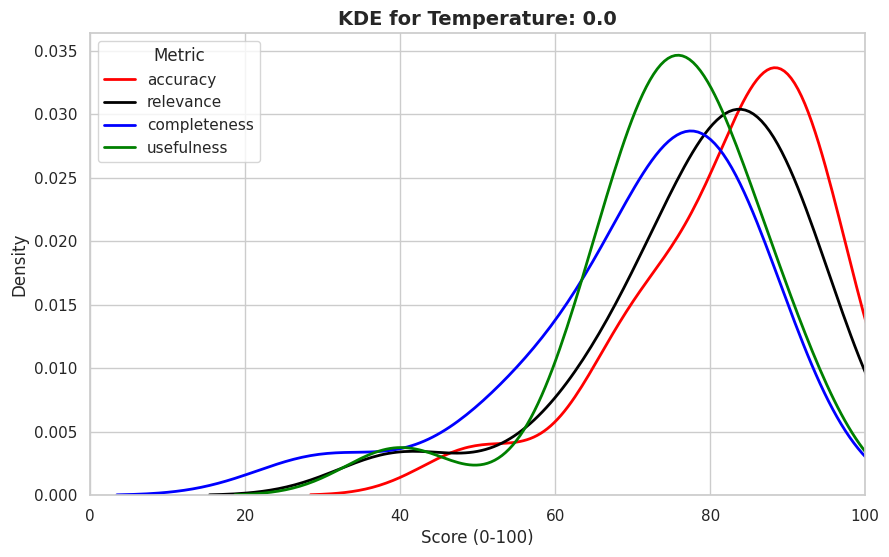

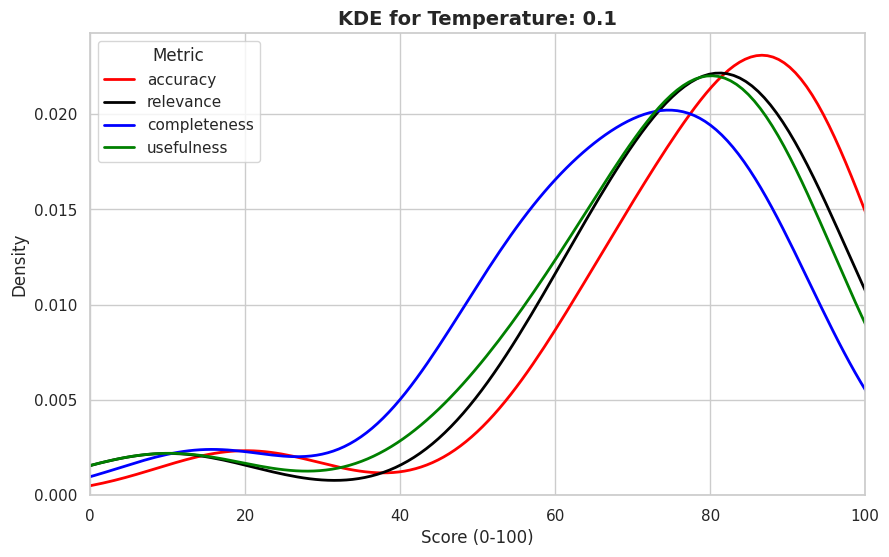

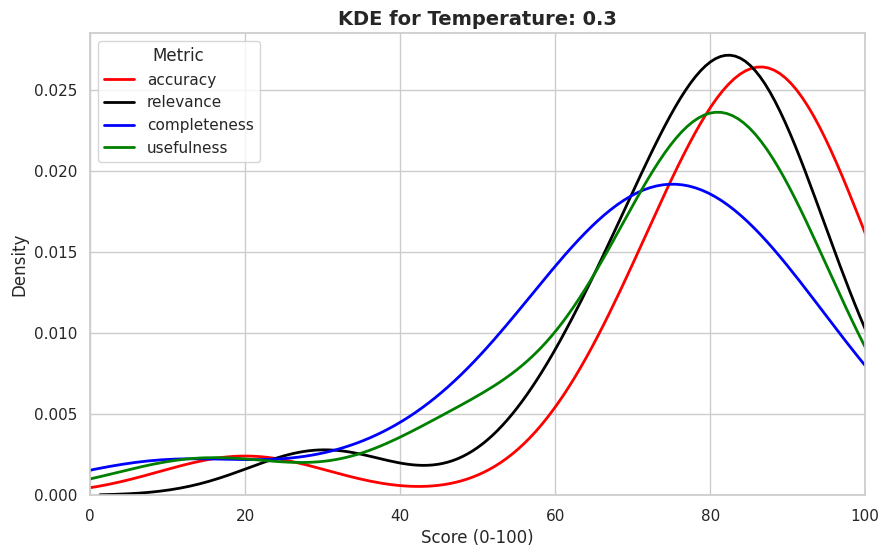

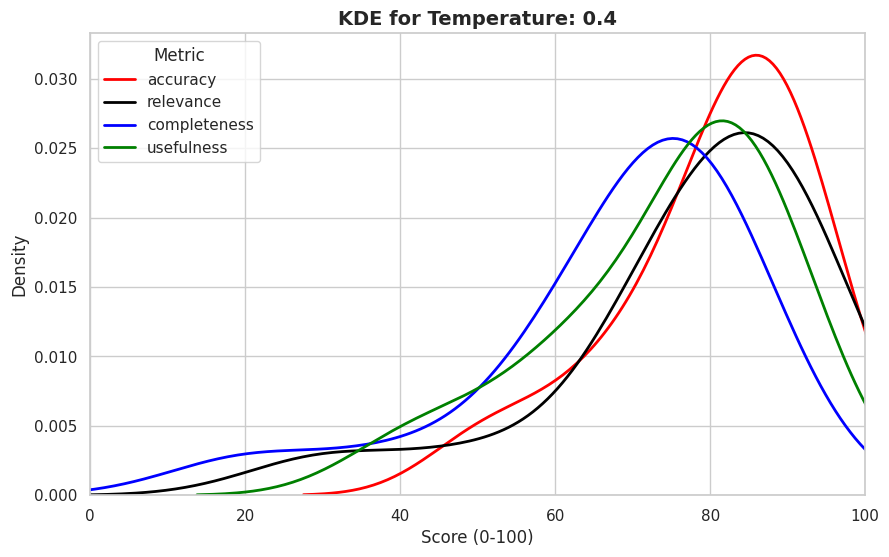

In [24]:
import seaborn as sns


# Set a clean style for better visualization
sns.set_theme(style="whitegrid")

for temperature in TEMPERATURES:
    plt.figure(figsize=(10, 6)) 
    
    for attr_name in COLORS.keys():
        scores = response_evaluation_scores_and_feedback[temperature][attr_name]
        
        sns.kdeplot(
            scores, 
            label=attr_name.replace('_score', ''), 
            linewidth=2,
            color=COLORS[attr_name],
        )
            
    plt.legend(title="Metric")
    plt.xlim(0, 100)
    plt.xlabel("Score (0-100)", fontsize=12)
    plt.ylabel("Density", fontsize=12)
    plt.title(f'KDE for Temperature: {temperature:.1f}', fontsize=14, fontweight='bold')
    plt.show()

A better visualization takes each metric and plots its KDEs for different temperatures in one plot:

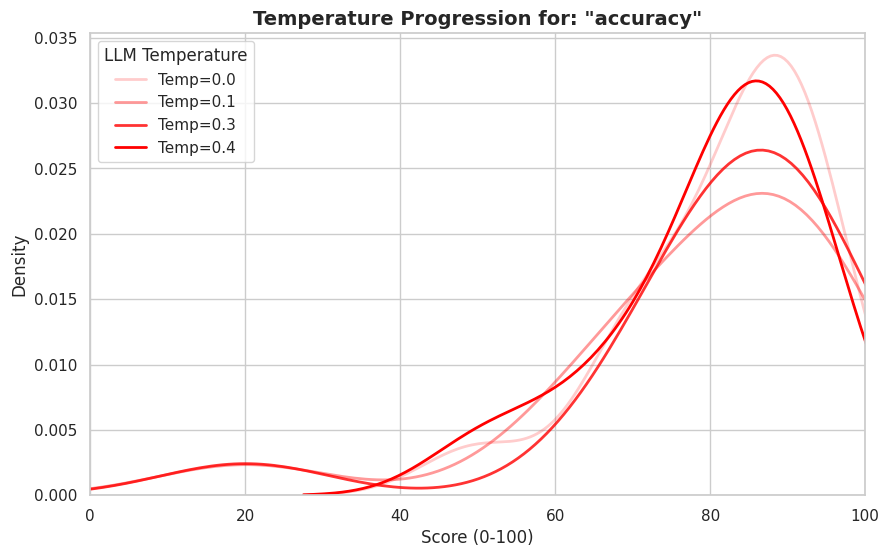

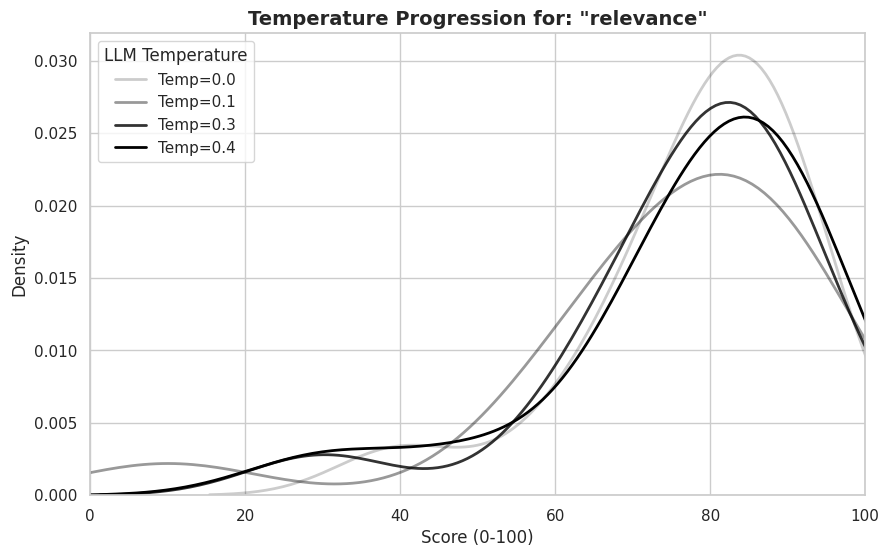

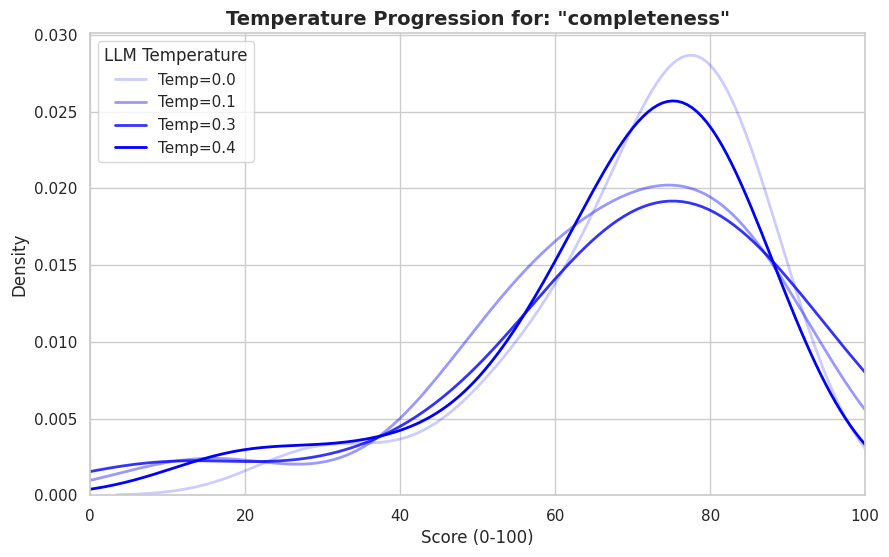

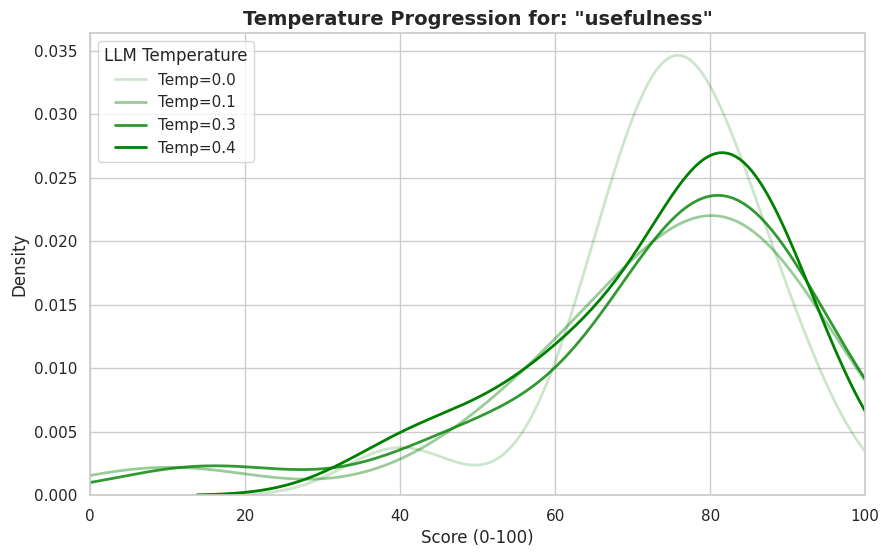

In [25]:
for attr_name in COLORS.keys():
    plt.figure(figsize=(10, 6)) 

    for temperature in TEMPERATURES:
        scores = response_evaluation_scores_and_feedback[temperature].get(attr_name)
                    
        sns.kdeplot(
            scores, 
            label=f'Temp={temperature:.1f}',
            linewidth=2,
            color=COLORS[attr_name],
            alpha=(0.1 + temperature) / (0.1 + min(TEMPERATURES) + max(TEMPERATURES)),
        )
        
    plt.legend(title="LLM Temperature")
    plt.xlim(0, 100)
    plt.xlabel("Score (0-100)", fontsize=12)
    plt.ylabel("Density", fontsize=12)
    plt.title(
        f'Temperature Progression for: "{attr_name.replace("_score", "")}"', 
        fontsize=14, 
        fontweight='bold',
    )
    plt.show()

## Tool use scores

Let's do the same thing with the tool use scores:

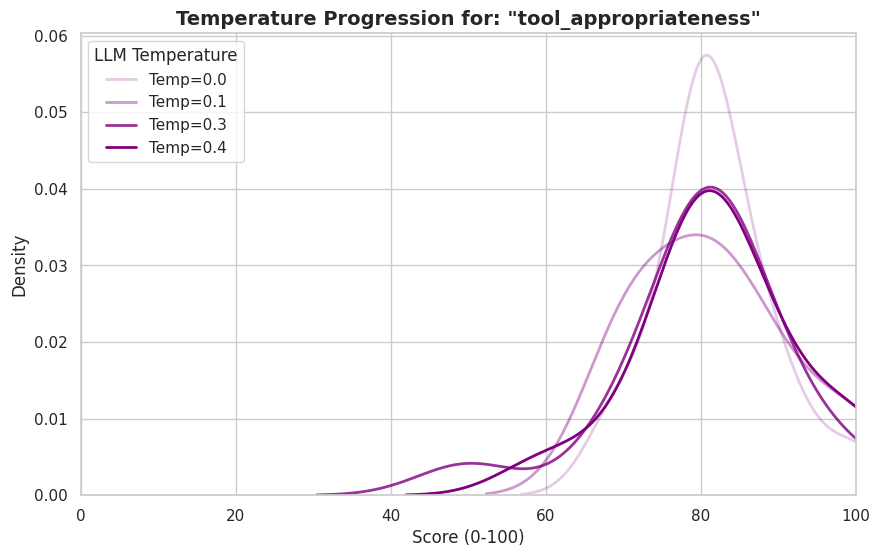

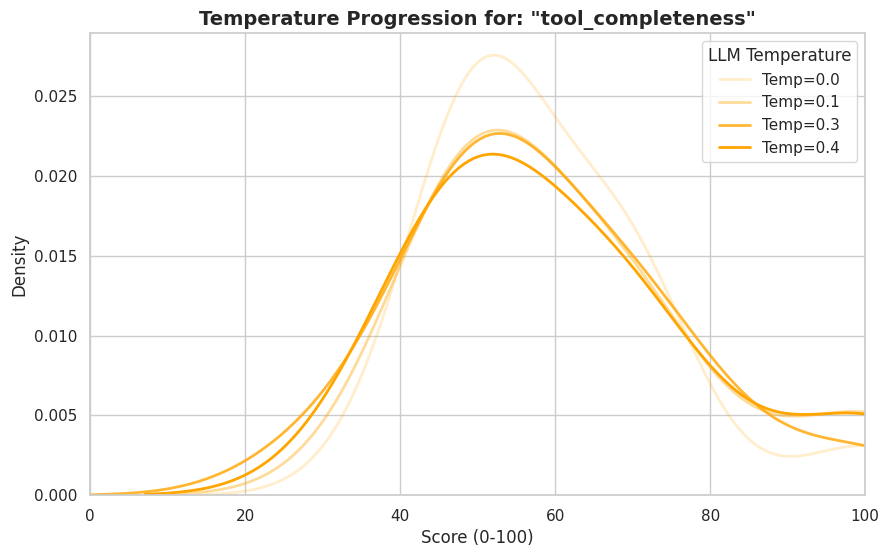

In [26]:
COLORS = {
 'tool_appropriateness_score': 'purple',
 'tool_completeness_score': 'orange',
}


for attr_name in COLORS.keys():
    plt.figure(figsize=(10, 6)) 

    for temperature in TEMPERATURES:
        scores = tool_use_evaluation_scores_and_feedback[temperature].get(attr_name)
                    
        sns.kdeplot(
            scores, 
            label=f'Temp={temperature:.1f}',
            linewidth=2,
            color=COLORS[attr_name],
            alpha=(0.1 + temperature) / (0.1 + min(TEMPERATURES) + max(TEMPERATURES)),
        )
        
    plt.legend(title="LLM Temperature")
    plt.xlim(0, 100)
    plt.xlabel("Score (0-100)", fontsize=12)
    plt.ylabel("Density", fontsize=12)
    plt.title(
        f'Temperature Progression for: "{attr_name.replace("_score", "")}"', 
        fontsize=14, 
        fontweight='bold',
    )
    plt.show()

## Overall feedback summary

In [27]:
from statistics import mean

all_scores = {}

for temperature in TEMPERATURES:
    for test_case in test_cases:        
        all_scores[temperature] = sum([
            tool_use_evaluation_scores_and_feedback[temperature][attribute]
            for attribute in tool_use_evaluation_scores_and_feedback[temperature]
            if 'score' in attribute
        ], start=[]) + sum([
            response_evaluation_scores_and_feedback[temperature][attribute]
            for attribute in response_evaluation_scores_and_feedback[temperature]
            if 'score' in attribute
        ], start=[])
        

for temperature in TEMPERATURES:
    print(f"""
          
          
      #############################################################################################
      For temperature: {temperature:.2f} the overall feedback summary is:
      {feedback_evaluations[temperature].summary}
      
      Strengths of the agent are:
      {feedback_evaluations[temperature].strengths}
      
      Whereas weaknesses and areas of improvement are:
      {feedback_evaluations[temperature].weaknesses}
      
      The average score across all metrics is: {mean(all_scores[temperature]):.2f}
      #############################################################################################
      
      
    """)
    


          
          
      #############################################################################################
      For temperature: 0.00 the overall feedback summary is:
      The agent's responses generally provide relevant information and address user queries effectively, particularly regarding energy management and charging strategies. However, many responses lack depth in cost analysis, fail to suggest optimal charging times based on solar energy availability, and do not fully utilize available tools for a comprehensive analysis. There is a recurring theme of missing actionable advice and specific recommendations tailored to the user's situation, particularly regarding historical data and comparative strategies. Additionally, while the tools selected are often appropriate, there are frequent omissions of key tools that would enhance the responses' completeness and effectiveness.
      
      Strengths of the agent are:
      The agent demonstrates a solid understandin